In [2]:
pip install yfinance pandas pytz 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import yfinance as yf

In [4]:
print("Data downloading...")
# soxl data download.
df = yf.download(tickers='SOXL',period='1mo',interval='5m')
# change timezone to Vancouver timezone.
df.index = df.index.tz_convert("America/Vancouver")

Data downloading...


[*********************100%***********************]  1 of 1 completed


In [5]:
df.head(10)

Price,Close,High,Low,Open,Volume
Ticker,SOXL,SOXL,SOXL,SOXL,SOXL
Datetime,,,,,
2026-08-24 06:30:00-07:00,111.120003,115.050003,110.699997,115.000000,8942851
2026-08-24 06:35:00-07:00,109.430000,112.379997,109.160004,111.099800,2639665
2026-08-24 06:40:00-07:00,108.160004,109.629997,108.000000,109.389999,2488216
2026-08-24 06:45:00-07:00,107.940002,109.664398,107.250000,108.150002,2585048
2026-08-24 06:50:00-07:00,107.089996,107.875000,106.000000,107.870102,2869587
2026-08-24 06:55:00-07:00,107.533096,108.379997,106.860001,107.095001,1412441
2026-08-24 07:00:00-07:00,106.425003,107.599998,106.084801,107.550003,1614473
2026-08-24 07:05:00-07:00,107.190002,107.580002,106.330002,106.430000,1013180


In [6]:
df.target = df.between_time('06:30', '13:00')
df.target.head(10)

C:\Users\woobi\AppData\Local\Temp\ipykernel_15564\1343469788.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.target = df.between_time('06:30', '13:00')


Price,Close,High,Low,Open,Volume
Ticker,SOXL,SOXL,SOXL,SOXL,SOXL
Datetime,,,,,
2026-08-24 06:30:00-07:00,111.120003,115.050003,110.699997,115.000000,8942851
2026-08-24 06:35:00-07:00,109.430000,112.379997,109.160004,111.099800,2639665
2026-08-24 06:40:00-07:00,108.160004,109.629997,108.000000,109.389999,2488216
2026-08-24 06:45:00-07:00,107.940002,109.664398,107.250000,108.150002,2585048
2026-08-24 06:50:00-07:00,107.089996,107.875000,106.000000,107.870102,2869587
2026-08-24 06:55:00-07:00,107.533096,108.379997,106.860001,107.095001,1412441
2026-08-24 07:00:00-07:00,106.425003,107.599998,106.084801,107.550003,1614473
2026-08-24 07:05:00-07:00,107.190002,107.580002,106.330002,106.430000,1013180


In [7]:
lowest_times = df.target.groupby(df.target.index.date)['Low'].idxmin()
lowest_times

Price,Low
Ticker,SOXL
2026-08-24,2026-08-24 06:50:00-07:00
2026-08-25,2026-08-25 07:30:00-07:00
2026-08-26,2026-08-26 07:25:00-07:00
2026-08-27,2026-08-27 06:55:00-07:00
2026-08-28,2026-08-28 10:05:00-07:00
2026-08-31,2026-08-31 09:05:00-07:00
2026-09-01,2026-09-01 06:40:00-07:00
2026-09-02,2026-09-02 06:55:00-07:00
2026-09-03,2026-09-03 06:35:00-07:00


In [8]:
highest_times = df.target.groupby(df.target.index.date)['High'].idxmax()
highest_times


Price,High
Ticker,SOXL
2026-08-24,2026-08-24 06:30:00-07:00
2026-08-25,2026-08-25 06:30:00-07:00
2026-08-26,2026-08-26 12:00:00-07:00
2026-08-27,2026-08-27 06:30:00-07:00
2026-08-28,2026-08-28 06:40:00-07:00
2026-08-31,2026-08-31 06:30:00-07:00
2026-09-01,2026-09-01 08:45:00-07:00
2026-09-02,2026-09-02 07:35:00-07:00
2026-09-03,2026-09-03 11:50:00-07:00


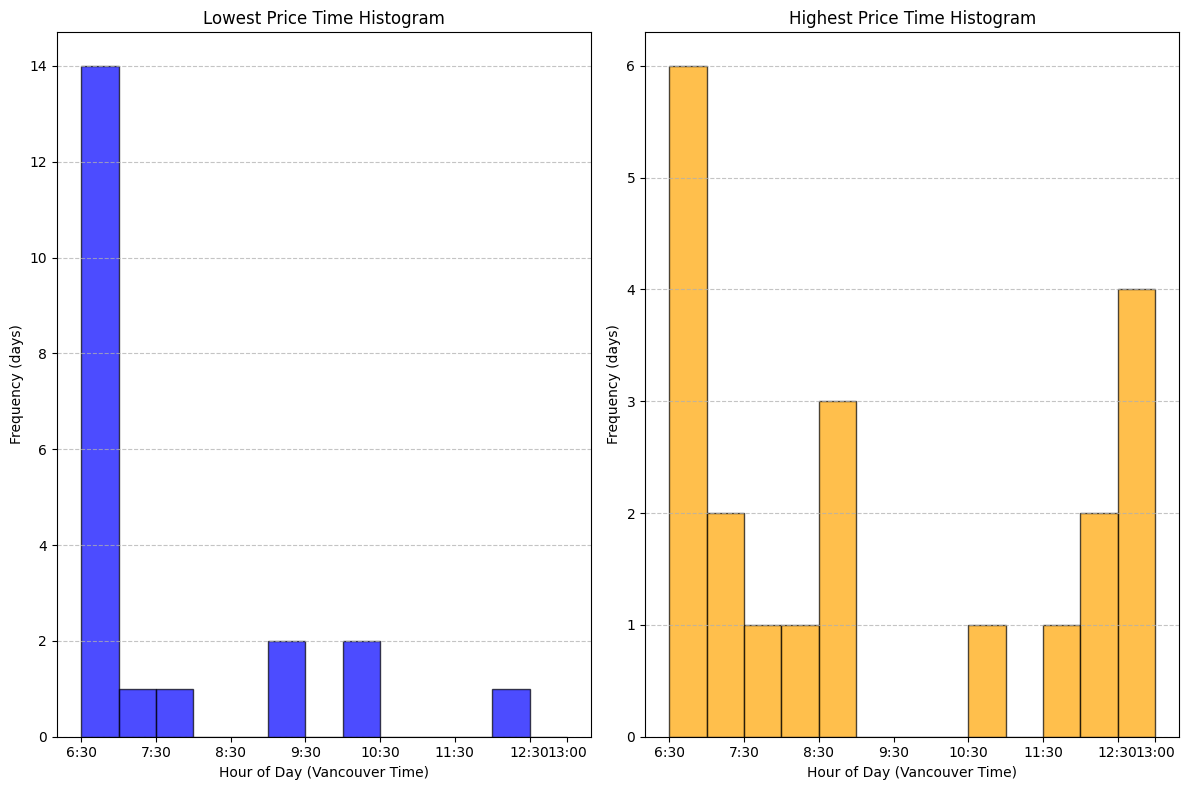

In [17]:
import matplotlib.pyplot as plt

low_series = lowest_times.iloc[:, 0]
high_series = highest_times.iloc[:, 0]

low_hours = low_series.dt.hour + low_series.dt.minute / 60
high_hours = high_series.dt.hour + high_series.dt.minute / 60

fig, axes = plt.subplots(1, 2, figsize=(12, 8))

axes[0].hist(low_hours,bins=13,range=(6.5,13),edgecolor='black',color='blue',alpha=0.7)
axes[0].set_title('Lowest Price Time Histogram')
axes[0].set_xlabel('Hour of Day (Vancouver Time)')
axes[0].set_ylabel('Frequency (days)') 
axes[0].set_xticks([6.5, 7.5, 8.5, 9.5, 10.5, 11.5, 12.5, 13.0])
axes[0].set_xticklabels(['6:30', '7:30', '8:30', '9:30', '10:30', '11:30', '12:30', '13:00'])
axes[0].grid(axis='y',linestyle='--',alpha=0.75)

axes[1].hist(high_hours,bins=13,range=(6.5,13),edgecolor='black',color='orange',alpha=0.7)
axes[1].set_title('Highest Price Time Histogram')       
axes[1].set_xlabel('Hour of Day (Vancouver Time)')
axes[1].set_ylabel('Frequency (days)')  
axes[1].set_xticks([6.5, 7.5, 8.5, 9.5, 10.5, 11.5, 12.5, 13.0])
axes[1].set_xticklabels(['6:30', '7:30', '8:30', '9:30', '10:30', '11:30', '12:30', '13:00'])
axes[1].grid(axis='y',linestyle='--',alpha=0.75)

plt.tight_layout()
plt.show()